# Course project

This notebook includes the code for the course project in the DTU course [Integrated Energy Grids](https://kurser.dtu.dk/course/2024-2025/46770?menulanguage=en)  and is modelling and analyzing the german energy system. 
 
The report is provided along this notebook, further explaining the results. 

### Imports

In [1]:
import pandas as pd
import pypsa
import matplotlib.pyplot as plt
import numpy as np

In [2]:
import os
import sys

# Set path to the directory containing base.py
module_path = os.path.abspath(".")

if module_path not in sys.path:
    sys.path.append(module_path)

import base  # now you can use base.build_network()
from visualization import *

In [3]:
country = "DEU"

## D. Introducing Storage Technology 
Add some storage technology/ies and investigate how they behave and what their impact is on the optimal system configuration. Discuss what strategies is your system using to balance the renewable generation at different time scales (intraday, seasonal, etc.)


### Adding Fixed Storage Unit

In [17]:
n_batt_fixed = base.build_network(solve=False)

c:\Users\mario\001_PROJ\Space\00X Studies\009 Integrated energy grids\46770_IEG\base.py:27: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  snapshots = pd.date_range(f"{year}-01-01", f"{year}-12-31 23:00", freq="H")
c:\Users\mario\001_PROJ\Space\00X Studies\009 Integrated energy grids\46770_IEG\base.py:98: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_daily["Inflow [MW]"] = df_daily["Inflow [GWh]"] * 1000 / 24  # MW average per hour
c:\Users\mario\001_PROJ\Space\00X Studies\009 Integrated energy grids\46770_IEG\base.py:100: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  inflow_ror_hourly = df_daily["Inflow [MW]"].resample("H").interpolate("

In [18]:
costs = base.get_costs()

In [ ]:
# add battery
storage_unit_e2p = 2

n_batt_fixed.add(
    "StorageUnit",
    "battery storage 2",
    bus=f"{country}_elec",
    carrier="battery storage",
    max_hours=storage_unit_e2p,
    capital_cost=costs.at["battery inverter", "capital_cost"]
    + storage_unit_e2p * costs.at["battery storage", "capital_cost"],
    efficiency_store=costs.at["battery inverter", "efficiency"],
    efficiency_dispatch=costs.at["battery inverter", "efficiency"],
    p_nom_extendable=True,
    cyclic_state_of_charge=True,
    overwrite=True
)


Index(['battery storage 2'], dtype='object')

In [20]:
n_batt_fixed.optimize(solver_name="gurobi")

Index(['DEU_elec'], dtype='object', name='Bus')


Index(['grid to battergy storage'], dtype='object', name='Link')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 7/7 [00:00<00:00, 25.27it/s]
INFO:linopy.io: Writing time: 2.02s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2617527


...

Solved in 84746 iterations and 12.69 seconds (5.41 work units)


INFO:gurobipy:Solved in 84746 iterations and 12.69 seconds (5.41 work units)


Optimal objective  3.076360042e+10


INFO:gurobipy:Optimal objective  3.076360042e+10
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 105131 primals, 219013 duals
Objective: 3.08e+10
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper, Link-ext-p-lower, Link-ext-p-upper, Store-ext-e-lower, Store-ext-e-upper, Store-energy_balance were not assigned to the network.


('ok', 'optimal')

System Cost: 30.76 billion euros

Optimal Generator and Storage Capacities (GW):
coal            0.000000
lignite        30.000000
biomass CHP     5.000000
OCGT           37.677619
ror             0.000000
onwind          4.108045
offwind         4.571301
solar          16.296205
Name: p_nom_opt, dtype: float64

Optimal Annual Energy Generation (GWh):
coal             0.000000
lignite        259.716618
biomass CHP     43.800000
OCGT           163.069339
ror              0.000000
onwind           7.594506
offwind         14.399626
solar           16.803391
dtype: float64


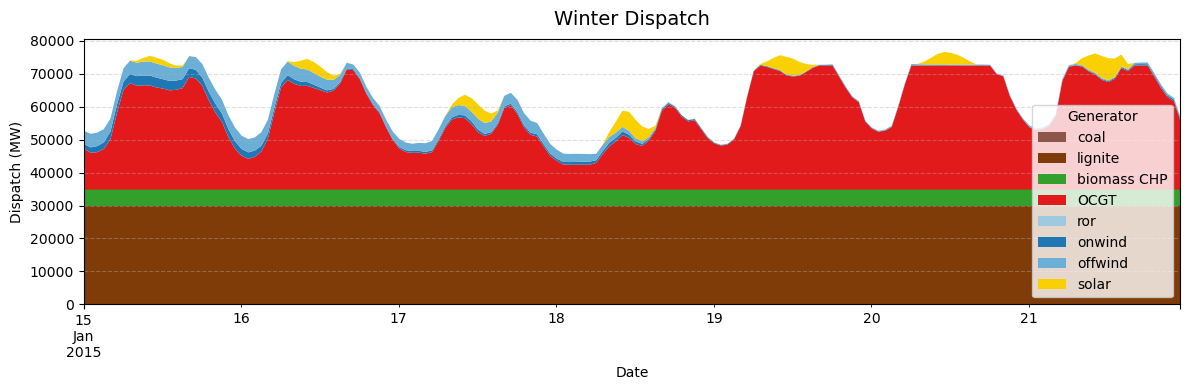

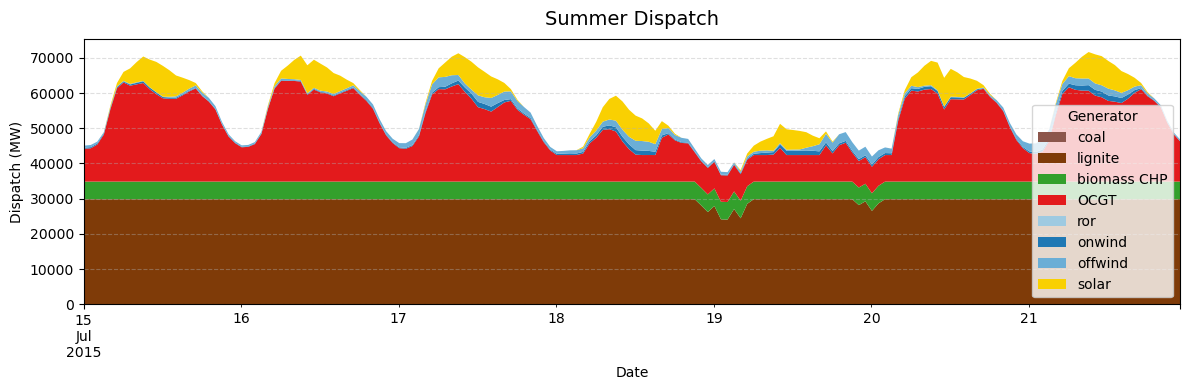

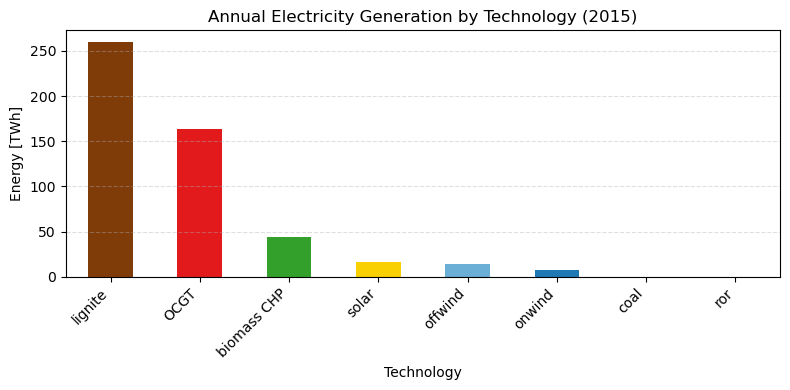

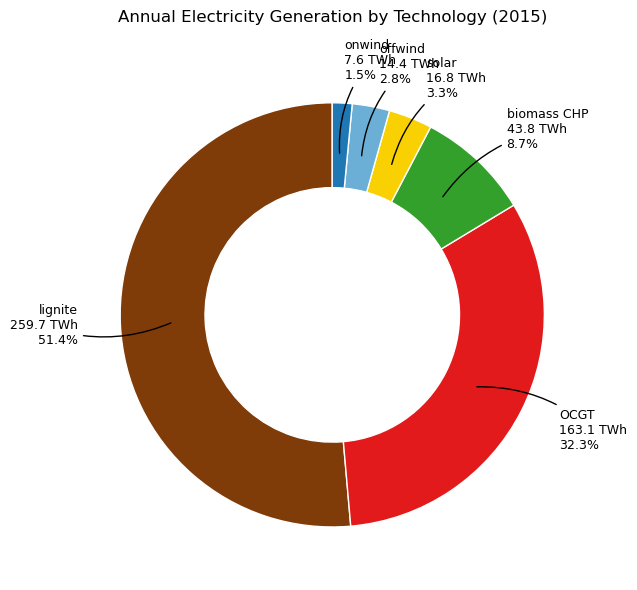

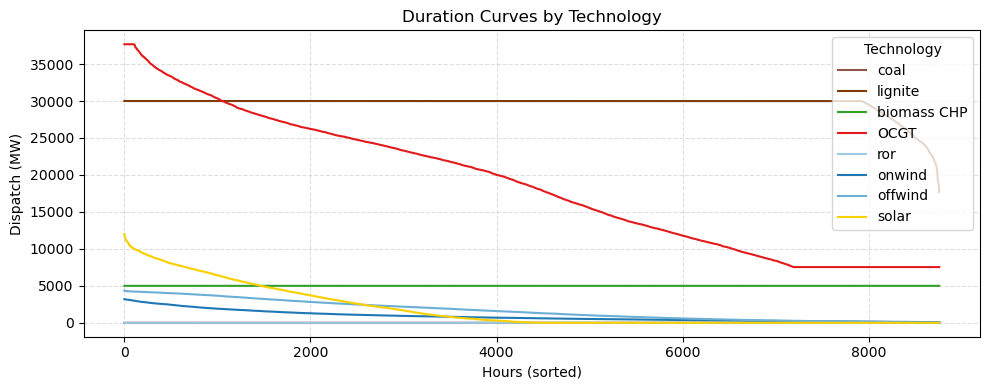

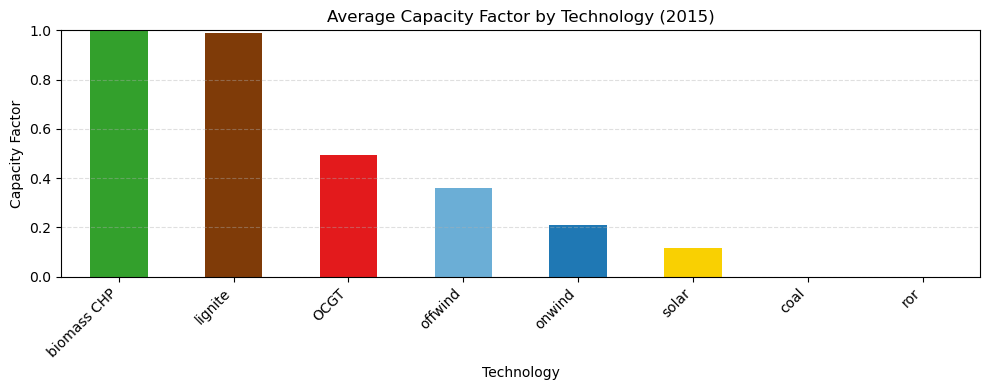

In [ ]:
print_summary(n_batt_fixed)
# Plot winter week
plot_dispatch_week(n_batt_fixed, "2015-01-15", "2015-01-21", "Winter Dispatch")
# Plot summer week
plot_dispatch_week(n_batt_fixed,"2015-07-15", "2015-07-21", "Summer Dispatch")
plot_generation_bar(n_batt_fixed)
plot_generation_pie(n_batt_fixed)
plot_duration_curves(n_batt_fixed)
plot_capacity_factors(n_batt_fixed)

<Axes: xlabel='snapshot', ylabel='battery'>

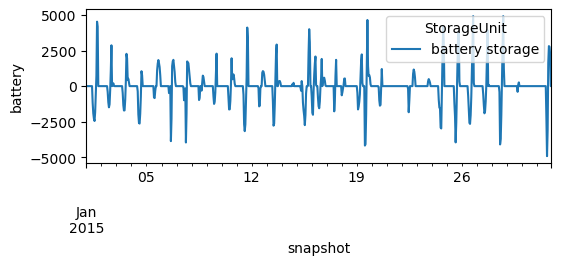

In [ ]:
n_batt_fixed.storage_units_t.p.loc["2015-01"].plot(figsize=(6, 2), ylabel="battery")

### Adding Battery as Store with Links

In [21]:
n_batt_store = base.build_network(solve=False)

c:\Users\mario\001_PROJ\Space\00X Studies\009 Integrated energy grids\46770_IEG\base.py:27: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  snapshots = pd.date_range(f"{year}-01-01", f"{year}-12-31 23:00", freq="H")
c:\Users\mario\001_PROJ\Space\00X Studies\009 Integrated energy grids\46770_IEG\base.py:98: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_daily["Inflow [MW]"] = df_daily["Inflow [GWh]"] * 1000 / 24  # MW average per hour
c:\Users\mario\001_PROJ\Space\00X Studies\009 Integrated energy grids\46770_IEG\base.py:100: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  inflow_ror_hourly = df_daily["Inflow [MW]"].resample("H").interpolate("

In [22]:
def annuity(r, n):
       return r / (1 - 1 / (1 + r)**n) if r > 0 else 1 / n

In [23]:
# battery store + link

#Create a new bus
n_batt_store.add("Bus",
          "elec_store",
          carrier = "battery storage",
          overwrite=True)

#Connect the store to the bus
n_batt_store.add("Store",
          "Battery Storage Store",
          bus = "elec_store",
          e_nom_extendable = True,
          e_cyclic = True,
          capital_cost = costs.at["battery storage", "capital_cost"],
          overwrite=True)

n_batt_store.add("Link",
          "grid to battergy storage",
          bus0 = f"{country}_elec",
          bus1 = "elec_store",
          p_nom_extendable = True,
          efficiency = costs.at["battery inverter", "efficiency"],
          capital_cost = costs.at["battery inverter", "efficiency"],
          overwrite=True)

n_batt_store.add("Link",
          "battery storage to grid",
          bus0 = "elec_store",
          bus1 = f"{country}_elec",
          p_nom_extendable = True,
          efficiency = costs.at["battery inverter", "efficiency"],
          capital_cost = costs.at["battery inverter", "efficiency"],
          overwrite=True
          )

Index(['battery storage to grid'], dtype='object')

In [24]:
n_batt_store.optimize(solver_name="gurobi")

Index(['DEU_elec'], dtype='object', name='Bus')
Index(['grid to battergy storage'], dtype='object', name='Link')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 7/7 [00:00<00:00, 24.40it/s]
INFO:linopy.io: Writing time: 2.06s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2617527


INFO:gurobipy:Set parameter LicenseID to value 2617527


...

Solved in 84746 iterations and 8.38 seconds (5.41 work units)


INFO:gurobipy:Solved in 84746 iterations and 8.38 seconds (5.41 work units)


Optimal objective  3.076360042e+10


INFO:gurobipy:Optimal objective  3.076360042e+10
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 105131 primals, 219013 duals
Objective: 3.08e+10
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper, Link-ext-p-lower, Link-ext-p-upper, Store-ext-e-lower, Store-ext-e-upper, Store-energy_balance were not assigned to the network.


('ok', 'optimal')

System Cost: 30.76 billion euros

Optimal Generator and Storage Capacities (GW):
coal            0.000000
lignite        30.000000
biomass CHP     5.000000
OCGT           37.677619
ror             0.000000
onwind          4.108045
offwind         4.571301
solar          16.296205
Name: p_nom_opt, dtype: float64

Optimal Annual Energy Generation (GWh):
coal             0.000000
lignite        259.716618
biomass CHP     43.800000
OCGT           163.069339
ror              0.000000
onwind           7.594506
offwind         14.399626
solar           16.803391
dtype: float64


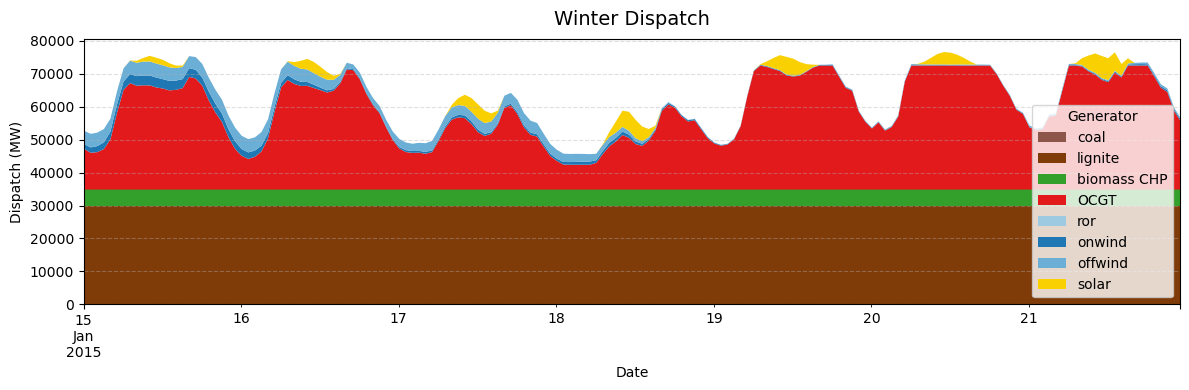

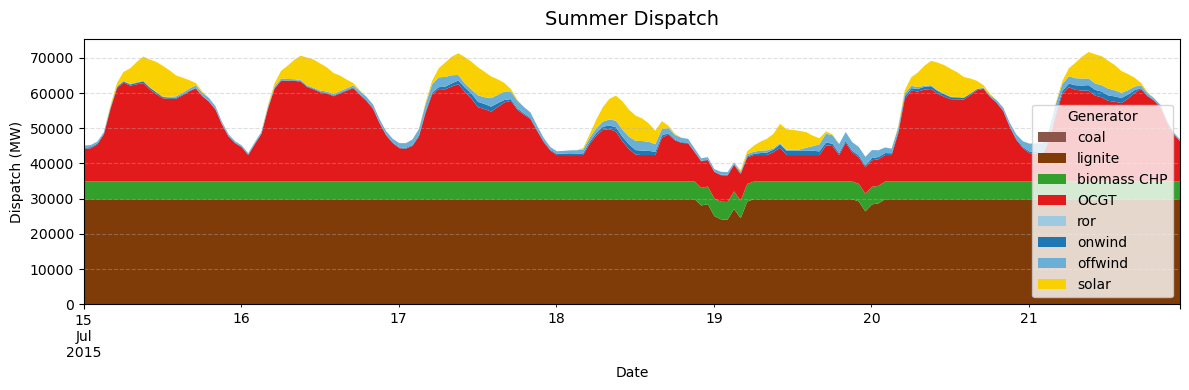

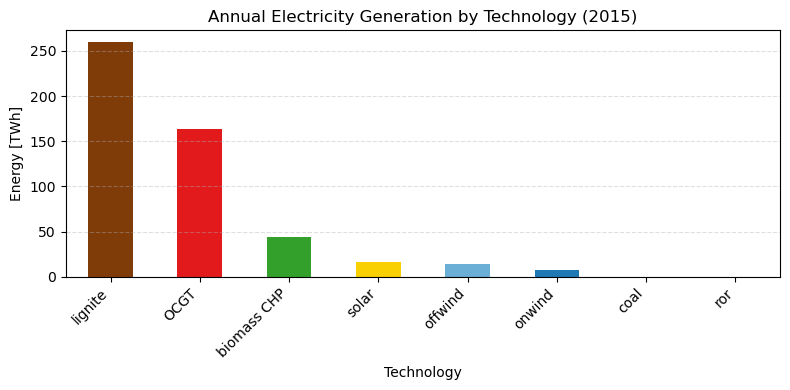

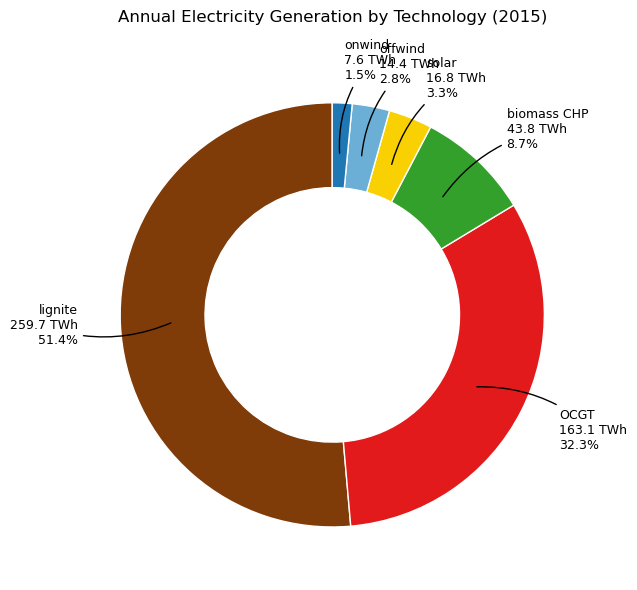

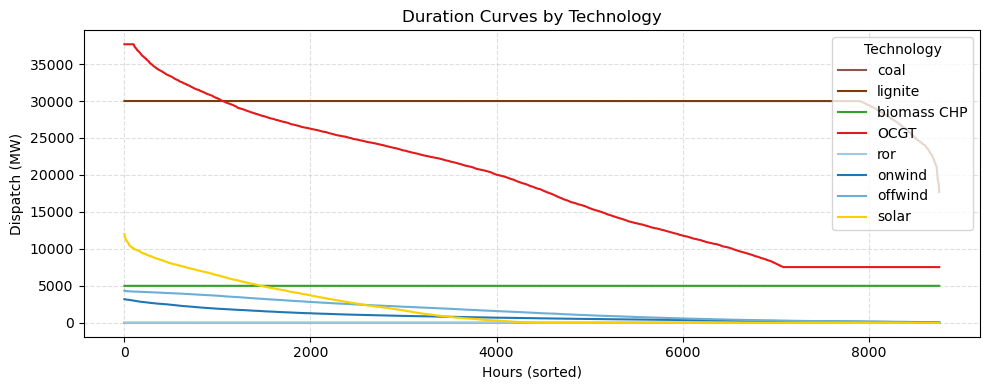

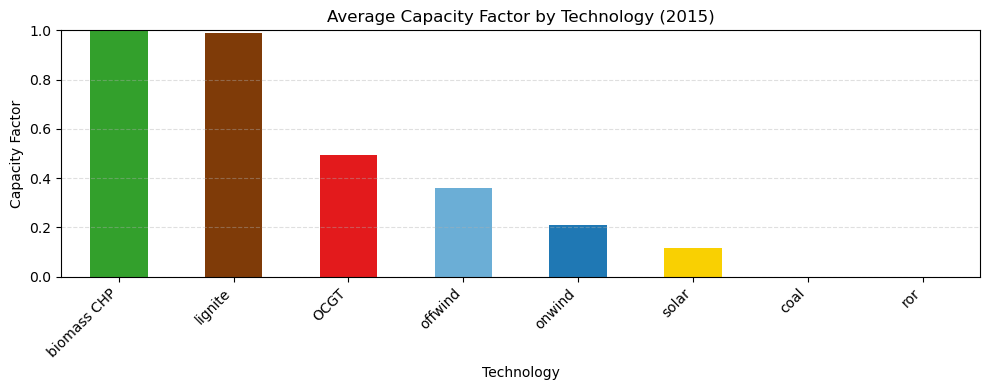

In [25]:
print_summary(n_batt_store)
# Plot winter week
plot_dispatch_week(n_batt_store, "2015-01-15", "2015-01-21", "Winter Dispatch")
# Plot summer week
plot_dispatch_week(n_batt_store,"2015-07-15", "2015-07-21", "Summer Dispatch")
plot_generation_bar(n_batt_store)
plot_generation_pie(n_batt_store)
plot_duration_curves(n_batt_store)
plot_capacity_factors(n_batt_store)

In [26]:
n_batt_store.links

,bus0,bus1,type,carrier,efficiency,active,build_year,lifetime,p_nom,p_nom_mod,...,shut_down_cost,min_up_time,min_down_time,up_time_before,down_time_before,ramp_limit_up,ramp_limit_down,ramp_limit_start_up,ramp_limit_shut_down,p_nom_opt
Link,,,,,,,,,,,,,,,,,,,,,
grid to battergy storage,DEU_elec,elec_store,,AC,0.955,True,0,inf,0.0,0.0,...,0.0,0,0,1,0,NaN,NaN,1.0,1.0,2871.341197
battery storage to grid,elec_store,DEU_elec,,battery storage,0.955,True,0,inf,0.0,0.0,...,0.0,0,0,1,0,NaN,NaN,1.0,1.0,3802.362615


In [27]:
n_batt_store.stores

,bus,type,carrier,e_nom,e_nom_mod,e_nom_extendable,e_nom_min,e_nom_max,e_min_pu,e_max_pu,...,sign,marginal_cost,marginal_cost_quadratic,marginal_cost_storage,capital_cost,standing_loss,active,build_year,lifetime,e_nom_opt
Store,,,,,,,,,,,,,,,,,,,,,
Battery Storage Store,elec_store,,battery storage,0.0,0.0,True,0.0,inf,0.0,1.0,...,1.0,0.0,0.0,0.0,17718.354182,0.0,True,0,inf,8632.960762


<Axes: xlabel='snapshot', ylabel='battery'>

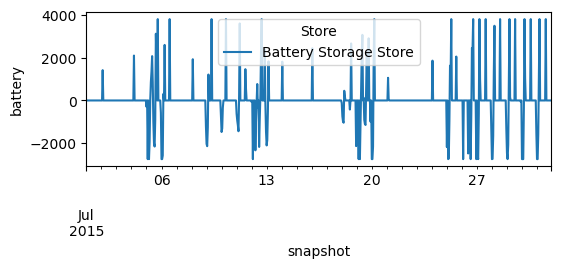

In [28]:
n_batt_store.stores_t.p.loc["2015-07"].plot(figsize=(6, 2), ylabel="battery")

<Axes: xlabel='snapshot', ylabel='battery'>

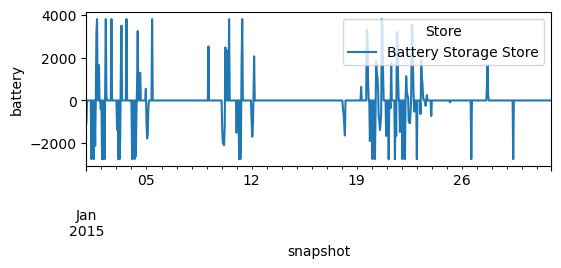

In [29]:
n_batt_store.stores_t.p.loc["2015-01"].plot(figsize=(6, 2), ylabel="battery")

### Adding Hydrogen Storage as Store with Links

In [31]:
n_H_store = base.build_network(solve=False)

c:\Users\mario\001_PROJ\Space\00X Studies\009 Integrated energy grids\46770_IEG\base.py:27: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  snapshots = pd.date_range(f"{year}-01-01", f"{year}-12-31 23:00", freq="H")
c:\Users\mario\001_PROJ\Space\00X Studies\009 Integrated energy grids\46770_IEG\base.py:98: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_daily["Inflow [MW]"] = df_daily["Inflow [GWh]"] * 1000 / 24  # MW average per hour
c:\Users\mario\001_PROJ\Space\00X Studies\009 Integrated energy grids\46770_IEG\base.py:100: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  inflow_ror_hourly = df_daily["Inflow [MW]"].resample("H").interpolate("

In [32]:
#Create a new carrier
n_H_store.add("Carrier",
              "H2")

#Create a new bus
n_H_store.add("Bus",
          "H2",
          carrier = "H2",
          overwrite=True)

#Connect the store to the bus
n_H_store.add("Store",
          "H2 Tank",
          bus = "H2",
          e_nom_extendable = True,
          e_cyclic = True,
          capital_cost = annuity(25, 0.07)*57000*(1+0.011),
          overwrite=True)

n_H_store.add("Link",
          "H2 Electrolysis",
          bus0 = f"{country}_elec",
          bus1 = "H2",
          p_nom_extendable = True,
          efficiency = 0.8,
          capital_cost = annuity(25, 0.07)*600000*(1+0.05),
          overwrite=True)

#Add the link "H2 Fuel Cell" that transports energy from the H2 bus (bus0) to the electricity bus (bus1)
#with 58% efficiency
n_H_store.add("Link",
          "H2 Fuel Cell",
          bus0 = "H2",
          bus1 = f"{country}_elec",
          p_nom_extendable = True,
          efficiency = 0.58,
          capital_cost = annuity(10, 0.07)*1300000*(1+0.05),
          overwrite=True)

Index(['H2 Fuel Cell'], dtype='object')

In [33]:
n_H_store.optimize(solver_name="gurobi")

Index(['DEU_elec'], dtype='object', name='Bus')


Index(['H2 Electrolysis'], dtype='object', name='Link')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 7/7 [00:00<00:00, 22.39it/s]
INFO:linopy.io: Writing time: 2.12s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2617527


...

Solved in 83396 iterations and 5.95 seconds (3.93 work units)


INFO:gurobipy:Solved in 83396 iterations and 5.95 seconds (3.93 work units)


Optimal objective  3.088515509e+10


INFO:gurobipy:Optimal objective  3.088515509e+10
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 105131 primals, 219013 duals
Objective: 3.09e+10
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper, Link-ext-p-lower, Link-ext-p-upper, Store-ext-e-lower, Store-ext-e-upper, Store-energy_balance were not assigned to the network.


('ok', 'optimal')

System Cost: 30.89 billion euros

Optimal Generator and Storage Capacities (GW):
coal            0.000000
lignite        30.000000
biomass CHP     5.000000
OCGT           41.340161
ror             0.000000
onwind          1.667861
offwind         5.296146
solar          10.865676
Name: p_nom_opt, dtype: float64

Optimal Annual Energy Generation (GWh):
coal             0.000000
lignite        258.381525
biomass CHP     43.800000
OCGT           172.112938
ror              0.000000
onwind           3.083360
offwind         16.682891
solar           11.203848
dtype: float64


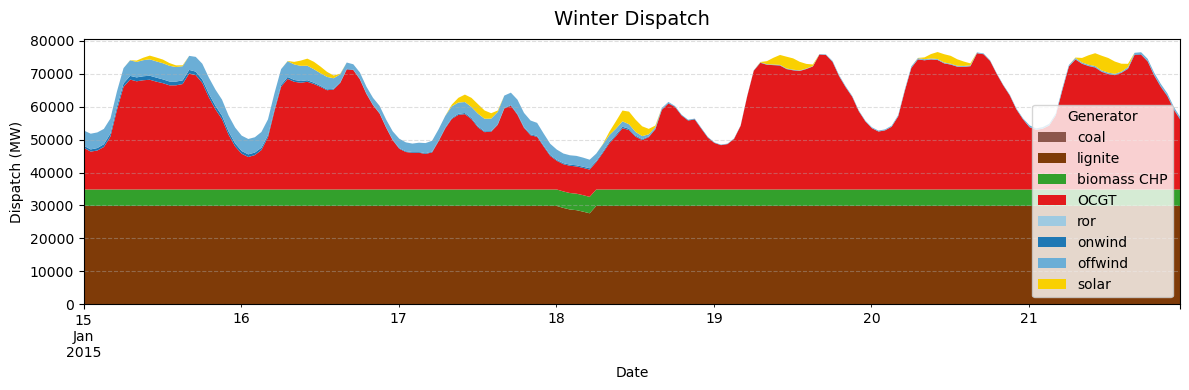

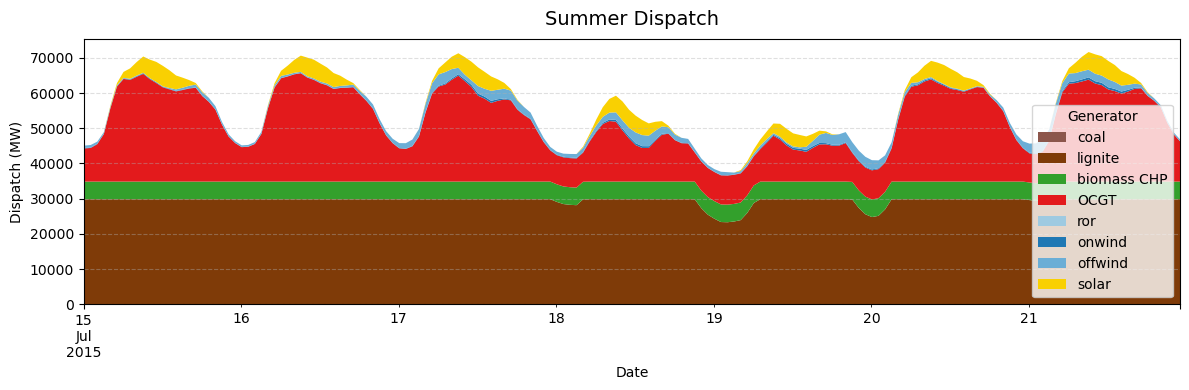

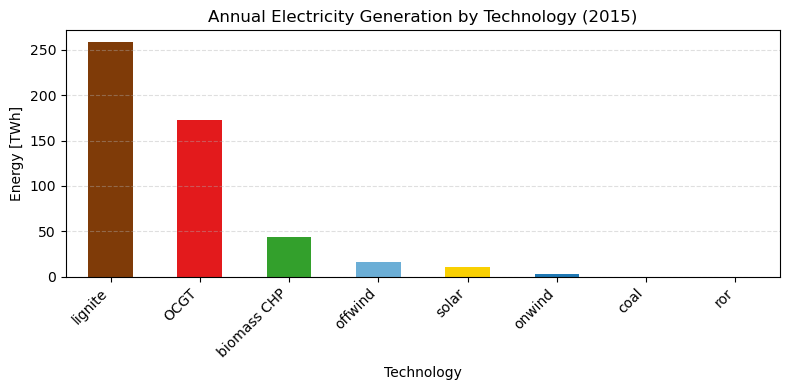

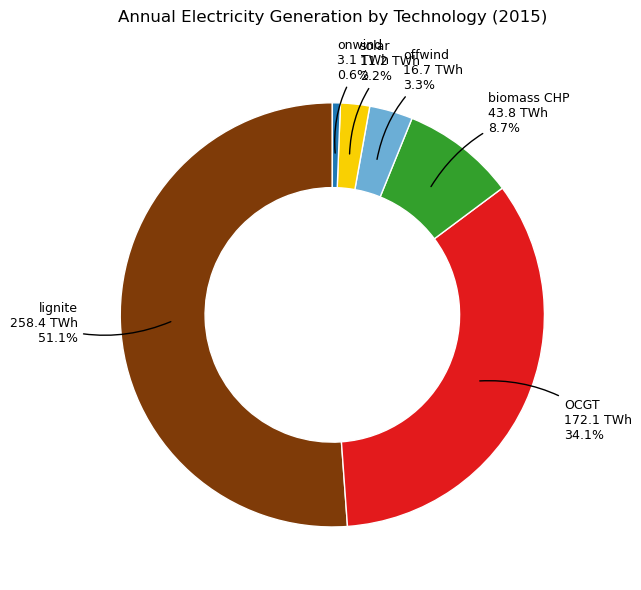

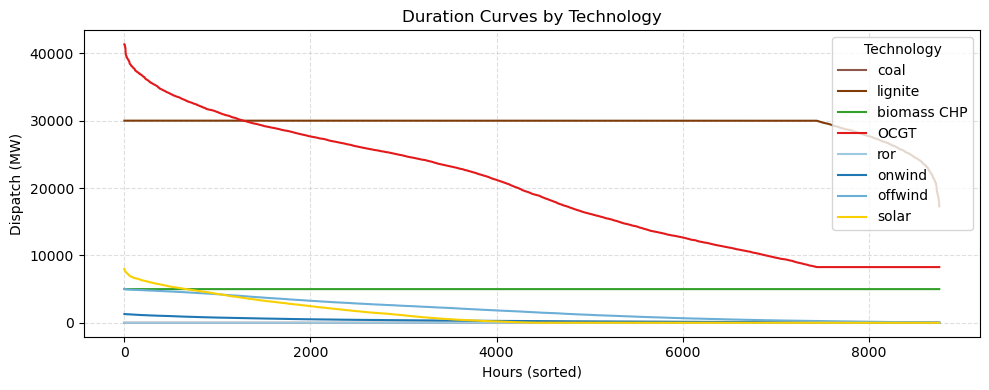

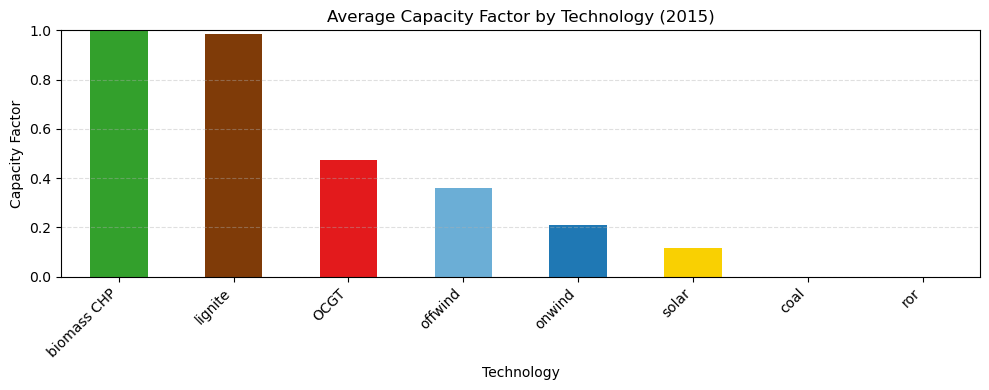

In [34]:
print_summary(n_H_store)
# Plot winter week
plot_dispatch_week(n_H_store, "2015-01-15", "2015-01-21", "Winter Dispatch")
# Plot summer week
plot_dispatch_week(n_H_store,"2015-07-15", "2015-07-21", "Summer Dispatch")
plot_generation_bar(n_H_store)
plot_generation_pie(n_H_store)
plot_duration_curves(n_H_store)
plot_capacity_factors(n_H_store)